# Credit Risk Modelling & Expected Loss Framework

## Objective

This project develops an end-to-end credit risk framework using Lending Club consumer-loan data. The objective is to estimate borrower-level Probability of Default (PD), calibrate predicted probabilities through out-of-time validation, estimate Loss Given Default (LGD) and Exposure at Default (EAD), and translate these components into portfolio Expected Credit Loss (EL) and stress-testing scenarios.

The framework follows:

\[
\text{Expected Loss} = PD \times LGD \times EAD
\]

## Modelling Approach

- Logistic Regression benchmark
- LightGBM nonlinear PD model
- Out-of-time train/validation/test design
- Isotonic probability calibration
- SHAP model interpretation
- Empirical recovery-based LGD estimation
- Loan-level EAD and Expected Loss
- Portfolio risk segmentation
- Scenario-based credit stress testing

## Key Results

Key results from the final model are:

- LightGBM out-of-time ROC-AUC: **0.7071**
- LightGBM out-of-time KS statistic: **0.3000**
- Calibrated mean test PD: **21.74%**
- Realised test default rate: **21.29%**
- Mature historical LGD: **89.62%**
- Base portfolio expected loss: **$706.9 million**
- Severe-stress expected loss: **$1.118 billion**
- Severe-stress increase vs. base: **58.16%**

The notebook below recomputes all results from the full Lending Club dataset.


## 1. Data and Target Definition

The analysis uses Lending Club consumer-loan originations from 2007–2018. The raw dataset contains approximately 2.26 million observations and 151 variables.

For probability-of-default modelling, only loans with resolved outcomes are retained. `Charged Off`, `Default`, and legacy charged-off statuses are classified as default events, while fully paid loans are classified as non-defaults. Current, late, grace-period, and unresolved loans are excluded from the supervised-learning target.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd

DATA_PATH = Path("accepted_2007_to_2018Q4.csv")

if not DATA_PATH.exists():
    raise FileNotFoundError(
        "Place 'accepted_2007_to_2018Q4.csv' in the same folder as this notebook "
        "or update DATA_PATH to its location."
    )

df = pd.read_csv(
    DATA_PATH,
    low_memory=False
)
print(f"Raw dataset: {df.shape[0]:,} loans × {df.shape[1]} variables")
print("\nLoan status distribution:")
print(df["loan_status"].value_counts(dropna=False))


Raw dataset: 2,260,701 loans × 151 variables

Loan status distribution:
loan_status
Fully Paid                                             1076751
Current                                                 878317
Charged Off                                             268559
Late (31-120 days)                                       21467
In Grace Period                                           8436
Late (16-30 days)                                         4349
Does not meet the credit policy. Status:Fully Paid        1988
Does not meet the credit policy. Status:Charged Off        761
Default                                                     40
NaN                                                         33
Name: count, dtype: int64


In [2]:
df["issue_d"] = pd.to_datetime(
    df["issue_d"],
    format="%b-%Y",
    errors="coerce"
)

print(
    f"Observation period: "
    f"{df['issue_d'].min():%B %Y} – {df['issue_d'].max():%B %Y}"
)


Observation period: June 2007 – December 2018


In [3]:
DEFAULT = [
    "Charged Off",
    "Default",
    "Does not meet the credit policy. Status:Charged Off"
]

NON_DEFAULT = [
    "Fully Paid",
    "Does not meet the credit policy. Status:Fully Paid"
]

model_df = df[
    df["loan_status"].isin(DEFAULT + NON_DEFAULT)
].copy()

model_df["default"] = model_df["loan_status"].isin(DEFAULT).astype(int)
model_df["issue_year"] = model_df["issue_d"].dt.year

print(f"Resolved modelling sample: {len(model_df):,} loans")
print(
    f"Defaults: {model_df['default'].sum():,} "
    f"({model_df['default'].mean():.2%})"
)
print(f"Non-defaults: {(model_df['default'] == 0).sum():,}")


Resolved modelling sample: 1,348,099 loans
Defaults: 269,360 (19.98%)
Non-defaults: 1,078,739


## 2. Out-of-Time Validation Design

A chronological split is used rather than a random train-test split:

- **Training:** 2007–2014
- **Validation:** 2015–2016
- **Test:** 2017–2018

This design provides a more realistic assessment of model performance on future lending cohorts and allows deterioration in discrimination or calibration across vintages to be measured.

A limitation is that recent cohorts contain only loans whose outcomes were already resolved, which may introduce maturity or outcome-selection bias.


In [4]:
train = model_df[
    model_df["issue_year"].between(2007, 2014)
].copy()

validation = model_df[
    model_df["issue_year"].between(2015, 2016)
].copy()

test = model_df[
    model_df["issue_year"].between(2017, 2018)
].copy()

split_summary = pd.DataFrame({
    "Sample": ["Train", "Validation", "Test"],
    "Period": ["2007–2014", "2015–2016", "2017–2018"],
    "Loans": [len(train), len(validation), len(test)],
    "Default Rate": [
        train["default"].mean(),
        validation["default"].mean(),
        test["default"].mean()
    ]
})

split_summary


,Sample,Period,Loans,Default Rate
0,Train,2007–2014,453809,0.170250
1,Validation,2015–2016,668651,0.215443
2,Test,2017–2018,225639,0.212920


### Vintage and Term Effects

Default rates vary materially across origination vintages and are consistently higher for 60-month loans. This supports retaining loan term as a PD predictor and reinforces the use of out-of-time validation.


In [5]:
term_vintage_summary = (
    model_df
    .groupby(["issue_year", "term"])["default"]
    .agg(["count", "mean"])
    .rename(columns={"mean": "default_rate"})
)

term_vintage_summary


count  default_rate
issue_year term                           
2007       36 months     603      0.262023
2008       36 months    2393      0.207271
2009       36 months    5281      0.136906
2010       36 months    9156      0.109218
           60 months    3381      0.223898
2011       36 months   14101      0.106305
           60 months    7620      0.235958
2012       36 months   43470      0.135795
           60 months    9897      0.276953
2013       36 months  100422      0.123260
           60 months   34382      0.251469
2014       36 months  162570      0.137264
           60 months   60533      0.311351
2015       36 months  283026      0.148863
           60 months   92520      0.363943
2016       36 months  232361      0.198484
           60 months   60744      0.364349
2017       36 months  128551      0.200185
           60 months   40770      0.329532
2018       36 months   41272      0.132487
           60 months   15046      0.226372

## 3. Feature Selection and Preprocessing

The PD model uses borrower and loan characteristics available at or near origination. Variables observed after origination—such as payments, recoveries, remaining principal and settlement outcomes—are excluded to prevent target leakage.

Lending Club's `grade` and `sub_grade` are deliberately excluded from the primary model because they embed the lender's own underwriting assessment.

Preprocessing includes:

- median imputation for numerical variables;
- one-hot encoding of categorical variables;
- standardisation for the Logistic Regression benchmark;
- conversion of employment length into an ordinal measure;
- construction of a midpoint FICO score.


In [6]:
FEATURES = [
    # Loan
    "loan_amnt",
    "term",
    "int_rate",
    "installment",
    "purpose",
    "application_type",

    # Borrower
    "emp_length",
    "home_ownership",
    "annual_inc",
    "verification_status",
    "dti",

    # Credit history
    "fico_range_low",
    "fico_range_high",
    "delinq_2yrs",
    "inq_last_6mths",
    "open_acc",
    "pub_rec",
    "revol_bal",
    "revol_util",
    "total_acc",

    # Extended credit information
    "acc_now_delinq",
    "tot_coll_amt",
    "tot_cur_bal",
    "acc_open_past_24mths",
    "avg_cur_bal",
    "bc_open_to_buy",
    "bc_util",
    "mort_acc",
    "num_accts_ever_120_pd",
    "num_actv_bc_tl",
    "num_actv_rev_tl",
    "num_il_tl",
    "num_op_rev_tl",
    "num_rev_accts",
    "num_tl_90g_dpd_24m",
    "num_tl_op_past_12m",
    "pct_tl_nvr_dlq",
    "percent_bc_gt_75",
    "pub_rec_bankruptcies",
    "tax_liens",
    "tot_hi_cred_lim",
    "total_bal_ex_mort",
    "total_bc_limit",
    "total_il_high_credit_limit"
]

feature_summary = pd.DataFrame({
    "dtype": model_df[FEATURES].dtypes.astype(str),
    "missing_pct": model_df[FEATURES].isna().mean() * 100,
    "n_unique": model_df[FEATURES].nunique()
}).sort_values("missing_pct", ascending=False)

feature_summary.head(15)


,dtype,missing_pct,n_unique
emp_length,object,5.826723,11
pct_tl_nvr_dlq,float64,5.224394,631
avg_cur_bal,float64,5.214602,76864
num_rev_accts,float64,5.213044,107
num_il_tl,float64,5.212970,114
tot_cur_bal,float64,5.212970,400464
total_il_high_credit_limit,float64,5.212970,162550
num_accts_ever_120_pd,float64,5.212970,39
tot_coll_amt,float64,5.212970,12871
num_op_rev_tl,float64,5.212970,74


In [7]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler


def engineer_features(data):
    X = data[FEATURES].copy()

    # Midpoint of reported FICO range at origination
    X["fico_score"] = (
        X["fico_range_low"] + X["fico_range_high"]
    ) / 2

    X.drop(
        columns=["fico_range_low", "fico_range_high"],
        inplace=True
    )

    # Convert employment length into an ordinal measure
    emp_map = {
        "< 1 year": 0,
        "1 year": 1,
        "2 years": 2,
        "3 years": 3,
        "4 years": 4,
        "5 years": 5,
        "6 years": 6,
        "7 years": 7,
        "8 years": 8,
        "9 years": 9,
        "10+ years": 10
    }

    X["emp_length"] = X["emp_length"].map(emp_map)

    return X


X_train = engineer_features(train)
X_val = engineer_features(validation)
X_test = engineer_features(test)

y_train = train["default"].astype(int)
y_val = validation["default"].astype(int)
y_test = test["default"].astype(int)

categorical_features = [
    "term",
    "purpose",
    "application_type",
    "home_ownership",
    "verification_status"
]

numeric_features = [
    col for col in X_train.columns
    if col not in categorical_features
]

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(
        handle_unknown="ignore",
        drop="first",
        min_frequency=50
    ))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])


## 4. Probability of Default Modelling

Two models are compared:

1. **Logistic Regression** — an interpretable benchmark commonly associated with traditional credit-risk modelling.
2. **LightGBM** — a nonlinear gradient-boosting model capable of capturing interactions and nonlinear borrower-risk relationships.

Performance is evaluated using ROC-AUC, PR-AUC, KS statistic and Brier score on chronological holdout samples.


### 4.1 Logistic Regression Benchmark


In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    brier_score_loss,
    roc_auc_score
)
from scipy.stats import ks_2samp
import warnings

warnings.filterwarnings(
    "ignore",
    message="Found unknown categories in columns"
)


def ks_statistic(y, p):
    y_array = np.asarray(y)
    return ks_2samp(
        p[y_array == 1],
        p[y_array == 0]
    ).statistic


def evaluate_model(y, p):
    return {
        "ROC-AUC": roc_auc_score(y, p),
        "PR-AUC": average_precision_score(y, p),
        "KS": ks_statistic(y, p),
        "Brier": brier_score_loss(y, p)
    }


logit_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        max_iter=1000,
        solver="lbfgs"
    ))
])

logit_model.fit(X_train, y_train)

p_train = logit_model.predict_proba(X_train)[:, 1]
p_val = logit_model.predict_proba(X_val)[:, 1]
p_test = logit_model.predict_proba(X_test)[:, 1]

logit_results = pd.DataFrame({
    "Train": evaluate_model(y_train, p_train),
    "Validation": evaluate_model(y_val, p_val),
    "Test": evaluate_model(y_test, p_test)
}).T

logit_results.round(4)


,ROC-AUC,PR-AUC,KS,Brier
Train,0.7030,0.3226,0.2950,0.1304
Validation,0.7224,0.4136,0.3238,0.1535
Test,0.6963,0.3631,0.2858,0.1570


### Calibration Drift

The training-period default rate is lower than those observed in later vintages. Comparing mean predicted PD with realised defaults therefore provides an initial test of temporal calibration stability.


In [9]:
pd_drift = pd.DataFrame({
    "Sample": ["Train", "Validation", "Test"],
    "Mean Predicted PD": [
        p_train.mean(),
        p_val.mean(),
        p_test.mean()
    ],
    "Actual Default Rate": [
        y_train.mean(),
        y_val.mean(),
        y_test.mean()
    ]
})

pd_drift


,Sample,Mean Predicted PD,Actual Default Rate
0,Train,0.170326,0.170250
1,Validation,0.168204,0.215443
2,Test,0.173830,0.212920


In [10]:
def calibration_table(y, p, n_bins=10):
    temp = pd.DataFrame({
        "actual": np.asarray(y),
        "pd": p
    })

    temp["decile"] = pd.qcut(
        temp["pd"],
        q=n_bins,
        duplicates="drop"
    )

    return (
        temp.groupby("decile", observed=True)
        .agg(
            loans=("actual", "size"),
            predicted_pd=("pd", "mean"),
            actual_default_rate=("actual", "mean")
        )
        .reset_index()
    )


validation_calibration = calibration_table(y_val, p_val)
validation_calibration


,decile,loans,predicted_pd,actual_default_rate
0,"(-0.00099999999999887, 0.0567]",66866,0.040733,0.046257
1,"(0.0567, 0.0781]",66865,0.067777,0.078890
2,"(0.0781, 0.0973]",66865,0.087777,0.106992
3,"(0.0973, 0.117]",66865,0.106968,0.139909
4,"(0.117, 0.138]",66865,0.127268,0.170568
5,"(0.138, 0.163]",66865,0.150239,0.204023
6,"(0.163, 0.195]",66864,0.178499,0.242672
7,"(0.195, 0.242]",66866,0.217225,0.293946
8,"(0.242, 0.326]",66865,0.279246,0.364526
9,"(0.326, 1.0]",66865,0.426306,0.506648


### 4.2 LightGBM Champion Model

LightGBM is trained using the same features and chronological data split as the Logistic Regression benchmark. The objective is to determine whether nonlinear relationships materially improve out-of-time default-risk discrimination.


In [11]:
from lightgbm import LGBMClassifier

warnings.filterwarnings(
    "ignore",
    message="X does not have valid feature names"
)

lgbm_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LGBMClassifier(
        objective="binary",
        n_estimators=500,
        learning_rate=0.05,
        num_leaves=31,
        max_depth=-1,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1,
        verbosity=-1
    ))
])

lgbm_model.fit(X_train, y_train)

p_train_lgbm = lgbm_model.predict_proba(X_train)[:, 1]
p_val_lgbm = lgbm_model.predict_proba(X_val)[:, 1]
p_test_lgbm = lgbm_model.predict_proba(X_test)[:, 1]

lgbm_results = pd.DataFrame({
    "Train": evaluate_model(y_train, p_train_lgbm),
    "Validation": evaluate_model(y_val, p_val_lgbm),
    "Test": evaluate_model(y_test, p_test_lgbm)
}).T

model_comparison = pd.concat(
    {
        "Logistic Regression": logit_results,
        "LightGBM": lgbm_results
    },
    names=["Model", "Sample"]
)

model_comparison.round(4)


ROC-AUC  PR-AUC      KS   Brier
Model               Sample                                     
Logistic Regression Train        0.7030  0.3226  0.2950  0.1304
                    Validation   0.7224  0.4136  0.3238  0.1535
                    Test         0.6963  0.3631  0.2858  0.1570
LightGBM            Train        0.7484  0.3920  0.3631  0.1244
                    Validation   0.7292  0.4233  0.3316  0.1522
                    Test         0.7071  0.3756  0.3002  0.1551

## 5. Probability Calibration

The LightGBM model retains discriminatory ability on later cohorts but systematically understates absolute default risk because the later portfolios exhibit higher realised default rates.

Isotonic regression is therefore fitted exclusively on the validation sample and subsequently applied to the untouched test sample.


In [12]:
from sklearn.isotonic import IsotonicRegression

calibrator = IsotonicRegression(
    y_min=0,
    y_max=1,
    out_of_bounds="clip"
)

calibrator.fit(p_val_lgbm, y_val)
p_test_cal = calibrator.transform(p_test_lgbm)

calibration_summary = pd.DataFrame({
    "Metric": [
        "Mean predicted PD before calibration",
        "Mean predicted PD after calibration",
        "Actual default rate",
        "Brier score before",
        "Brier score after",
        "ROC-AUC after",
        "KS after"
    ],
    "Value": [
        p_test_lgbm.mean(),
        p_test_cal.mean(),
        y_test.mean(),
        brier_score_loss(y_test, p_test_lgbm),
        brier_score_loss(y_test, p_test_cal),
        roc_auc_score(y_test, p_test_cal),
        ks_statistic(y_test, p_test_cal)
    ]
})

calibration_summary


,Metric,Value
0,Mean predicted PD before calibration,0.168029
1,Mean predicted PD after calibration,0.217439
2,Actual default rate,0.212920
3,Brier score before,0.155090
4,Brier score after,0.153221
5,ROC-AUC after,0.707044
6,KS after,0.300010


In [13]:
test_calibration = calibration_table(y_test, p_test_cal)
test_calibration


,decile,loans,predicted_pd,actual_default_rate
0,"(-0.001, 0.0518]",23436,0.034456,0.039085
1,"(0.0518, 0.0937]",23025,0.075409,0.082345
2,"(0.0937, 0.126]",21341,0.109251,0.114240
3,"(0.126, 0.159]",24337,0.144524,0.148169
4,"(0.159, 0.188]",21091,0.175167,0.189133
5,"(0.188, 0.229]",23620,0.210370,0.215919
6,"(0.229, 0.274]",22522,0.250344,0.255040
7,"(0.274, 0.337]",25358,0.308382,0.303928
8,"(0.337, 0.42]",19383,0.378440,0.356704
9,"(0.42, 1.0]",21526,0.520914,0.452151


## 6. Model Interpretation

SHAP values are used to assess both global feature importance and direction of influence on predicted default risk.

The dominant risk drivers include interest rate, loan term, annual income, recent credit-account growth, loan amount, debt-to-income ratio and FICO score.

Interest rate requires careful interpretation because Lending Club pricing itself reflects underwriting information; it therefore partly embeds the lender's prior assessment of borrower risk.


In [14]:
import warnings

warnings.filterwarnings(
    "ignore",
    message="LightGBM binary classifier with TreeExplainer shap values output has changed"
)

import shap

X_shap_raw = X_test.sample(
    n=min(10_000, len(X_test)),
    random_state=42
)

X_shap = (
    lgbm_model
    .named_steps["preprocessor"]
    .transform(X_shap_raw)
)

feature_names = (
    lgbm_model
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

model = lgbm_model.named_steps["model"]

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_shap)

if isinstance(shap_values, list):
    shap_values = shap_values[1]

mean_abs_shap = np.abs(shap_values).mean(axis=0)

shap_importance = (
    pd.DataFrame({
        "feature": feature_names,
        "mean_abs_shap": mean_abs_shap
    })
    .sort_values("mean_abs_shap", ascending=False)
)

shap_importance.head(20)


,feature,mean_abs_shap
1,num__int_rate,0.395318
38,cat__term_ 60 months,0.221960
4,num__annual_inc,0.179383
16,num__acc_open_past_24mths,0.137694
0,num__loan_amnt,0.117524
5,num__dti,0.105087
37,num__fico_score,0.091536
55,cat__home_ownership_RENT,0.059486
35,num__total_bc_limit,0.051369
28,num__num_tl_op_past_12m,0.048643


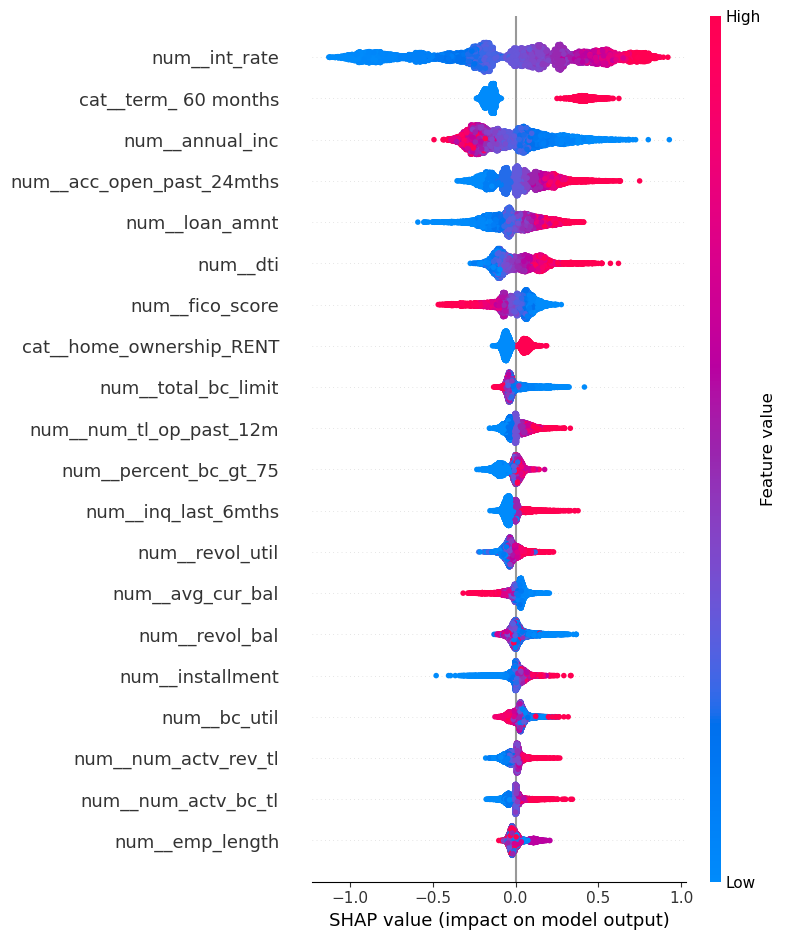

In [15]:
shap.summary_plot(
    shap_values,
    X_shap,
    feature_names=feature_names,
    max_display=20
)


## 7. Loss Given Default

For defaulted loans, exposure immediately before loss is approximated as:

\[
EAD_{\text{default}} = \text{Funded Amount} - \text{Principal Repaid}
\]

Net recoveries are defined as:

\[
\text{Net Recovery} = \text{Recoveries} - \text{Collection Recovery Fees}
\]

Realised LGD is then approximated by:

\[
LGD = 1 - \frac{\text{Net Recovery}}{EAD_{\text{default}}}
\]

LGD values are bounded to the economically meaningful interval \([0,1]\).


In [16]:
lgd_cols = [
    "funded_amnt",
    "total_rec_prncp",
    "recoveries",
    "collection_recovery_fee",
    "loan_status"
]

defaults = model_df.loc[
    model_df["default"] == 1,
    lgd_cols
].copy()

defaults["ead_default"] = (
    defaults["funded_amnt"]
    - defaults["total_rec_prncp"]
)

defaults["net_recovery"] = (
    defaults["recoveries"]
    - defaults["collection_recovery_fee"]
)

print(f"Default observations: {len(defaults):,}")
print(f"Non-positive EAD observations: {(defaults['ead_default'] <= 0).sum():,}")
print(f"Net recoveries above reconstructed EAD: {(defaults['net_recovery'] > defaults['ead_default']).sum():,}")


Default observations: 269,360
Non-positive EAD observations: 22
Net recoveries above reconstructed EAD: 87


In [17]:
lgd_df = defaults[
    defaults["ead_default"] > 0
].copy()

lgd_df["lgd_raw"] = (
    1 -
    lgd_df["net_recovery"]
    / lgd_df["ead_default"]
)

lgd_df["lgd"] = lgd_df["lgd_raw"].clip(0, 1)
lgd_df["recovery_rate"] = 1 - lgd_df["lgd"]

lgd_df["lgd"].describe(
    percentiles=[0.05, 0.25, 0.50, 0.75, 0.95]
)


count    269338.000000
mean          0.908693
std           0.110974
min           0.000000
5%            0.652071
25%           0.880613
50%           0.915469
75%           1.000000
95%           1.000000
max           1.000000
Name: lgd, dtype: float64

In [18]:
lgd_analysis = model_df.loc[lgd_df.index].copy()
lgd_analysis["lgd"] = lgd_df["lgd"]

lgd_by_vintage = (
    lgd_analysis
    .groupby("issue_year")["lgd"]
    .agg(["count", "mean", "median"])
)

lgd_by_vintage


,count,mean,median
issue_year,,,
2007,158,0.918271,0.955441
2008,496,0.926346,0.974606
2009,723,0.922923,0.955432
2010,1757,0.920518,0.954972
2011,3297,0.914301,0.942881
2012,8644,0.896836,0.903900
2013,21024,0.885546,0.878001
2014,41162,0.891173,0.902420
2015,75800,0.899920,0.915879


### Mature Historical LGD

Recent defaults may not have had sufficient time for recoveries to be realised. To reduce recovery-window censoring, the base-case portfolio LGD is estimated using defaulted loans originated through 2015.


In [19]:
mature_lgd = lgd_analysis[
    lgd_analysis["issue_year"] <= 2015
].copy()

BASE_LGD = mature_lgd["lgd"].mean()

print(f"Mature default observations: {len(mature_lgd):,}")
print(f"Mean mature LGD: {BASE_LGD:.2%}")
print(f"Median mature LGD: {mature_lgd['lgd'].median():.2%}")


Mature default observations: 153,061
Mean mature LGD: 89.62%
Median mature LGD: 91.48%


## 8. Expected Credit Loss Framework

Loan-level expected loss is calculated as:

\[
EL_i = PD_i \times LGD \times EAD_i
\]

where:

- `PD` is the calibrated LightGBM probability of default;
- `LGD` is the mature historical portfolio LGD;
- `EAD` is funded loan exposure at origination.


In [20]:
portfolio = test.copy()

portfolio["pd"] = p_test_cal
portfolio["lgd"] = BASE_LGD
portfolio["ead"] = portfolio["funded_amnt"]

portfolio["expected_loss"] = (
    portfolio["pd"]
    * portfolio["lgd"]
    * portfolio["ead"]
)

portfolio["expected_loss_rate"] = (
    portfolio["expected_loss"]
    / portfolio["ead"]
)

portfolio_summary = pd.DataFrame({
    "Metric": [
        "Loans",
        "Total EAD",
        "Expected Loss",
        "Portfolio EL Rate",
        "Average PD",
        "LGD Assumption"
    ],
    "Value": [
        len(portfolio),
        portfolio["ead"].sum(),
        portfolio["expected_loss"].sum(),
        portfolio["expected_loss"].sum() / portfolio["ead"].sum(),
        portfolio["pd"].mean(),
        BASE_LGD
    ]
})

portfolio_summary


,Metric,Value
0,Loans,2.256390e+05
1,Total EAD,3.259579e+09
2,Expected Loss,7.069405e+08
3,Portfolio EL Rate,2.168809e-01
4,Average PD,2.174388e-01
5,LGD Assumption,8.961784e-01


## 9. Portfolio Risk Segmentation

Loans are divided into five PD-based risk bands from **Very Low** to **Very High** risk.

The realised default rate should increase across the predicted-risk bands if the model is successfully ranking borrower credit quality.


In [21]:
portfolio["risk_band"] = pd.qcut(
    portfolio["pd"],
    q=5,
    labels=[
        "Very Low",
        "Low",
        "Medium",
        "High",
        "Very High"
    ],
    duplicates="drop"
)

risk_summary = (
    portfolio.groupby("risk_band", observed=True)
    .agg(
        loans=("default", "size"),
        ead=("ead", "sum"),
        avg_pd=("pd", "mean"),
        actual_default_rate=("default", "mean"),
        expected_loss=("expected_loss", "sum")
    )
)

risk_summary["el_rate"] = (
    risk_summary["expected_loss"]
    / risk_summary["ead"]
)

risk_summary


,loans,ead,avg_pd,actual_default_rate,expected_loss,el_rate
risk_band,,,,,,
Very Low,46461,590774950.0,0.054751,0.060524,2.866690e+07,0.048524
Low,45678,546504700.0,0.128044,0.132318,6.273325e+07,0.114790
Medium,44711,591268925.0,0.193764,0.203283,1.030820e+08,0.174340
High,47880,745079650.0,0.281082,0.280931,1.889293e+08,0.253569
Very High,40909,785951175.0,0.453408,0.406928,3.235291e+08,0.411640


## 10. Credit Stress Testing

Illustrative downturn scenarios apply simultaneous shocks to PD and LGD to estimate portfolio sensitivity to deteriorating credit conditions.

These scenarios are sensitivity analyses rather than regulatory stress-test calibrations:

- Base
- Moderate downturn
- Severe downturn
- Extreme stress


In [22]:
scenarios = {
    "Base": {
        "pd_multiplier": 1.00,
        "lgd_add": 0.00
    },
    "Moderate downturn": {
        "pd_multiplier": 1.25,
        "lgd_add": 0.03
    },
    "Severe downturn": {
        "pd_multiplier": 1.50,
        "lgd_add": 0.05
    },
    "Extreme stress": {
        "pd_multiplier": 2.00,
        "lgd_add": 0.10
    }
}

stress_results = []

for name, s in scenarios.items():
    stressed_pd = np.clip(
        portfolio["pd"] * s["pd_multiplier"],
        0,
        1
    )

    stressed_lgd = min(
        BASE_LGD + s["lgd_add"],
        1
    )

    stressed_el = (
        stressed_pd
        * stressed_lgd
        * portfolio["ead"]
    )

    stress_results.append({
        "scenario": name,
        "avg_pd": stressed_pd.mean(),
        "lgd": stressed_lgd,
        "expected_loss": stressed_el.sum(),
        "el_rate": stressed_el.sum() / portfolio["ead"].sum()
    })

stress_table = pd.DataFrame(stress_results)

base_el = stress_table.loc[
    stress_table["scenario"] == "Base",
    "expected_loss"
].iloc[0]

stress_table["incremental_loss"] = (
    stress_table["expected_loss"] - base_el
)

stress_table["increase_vs_base"] = (
    stress_table["expected_loss"] / base_el - 1
)

stress_table


,scenario,avg_pd,lgd,expected_loss,el_rate,incremental_loss,increase_vs_base
0,Base,0.217439,0.896178,7.069405e+08,0.216881,0.000000e+00,0.000000
1,Moderate downturn,0.271795,0.926178,9.132353e+08,0.280170,2.062948e+08,0.291814
2,Severe downturn,0.325863,0.946178,1.118083e+09,0.343015,4.111430e+08,0.581581
3,Extreme stress,0.426923,0.996178,1.533463e+09,0.470448,8.265227e+08,1.169154


## 11. Model and Portfolio Results


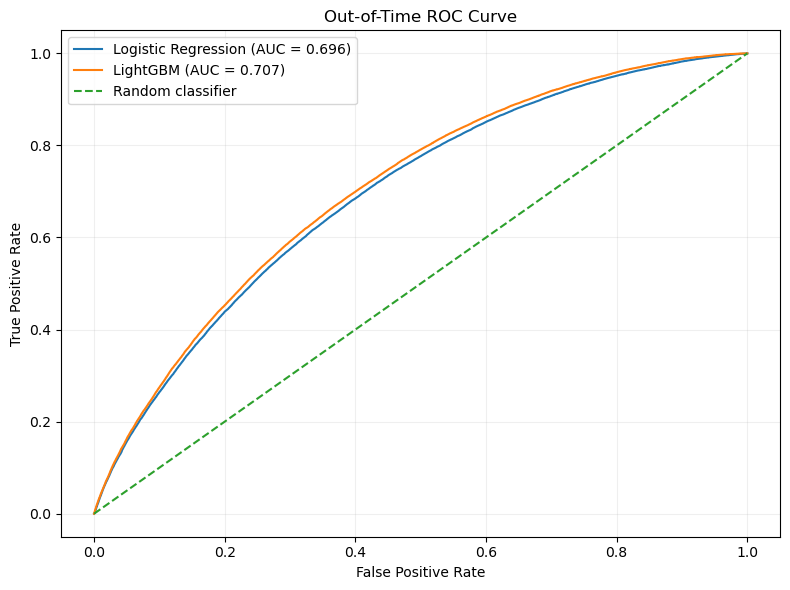

In [23]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve
from sklearn.calibration import calibration_curve

fpr_logit, tpr_logit, _ = roc_curve(y_test, p_test)
fpr_lgbm, tpr_lgbm, _ = roc_curve(y_test, p_test_lgbm)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr_logit,
    tpr_logit,
    label=f"Logistic Regression (AUC = {roc_auc_score(y_test, p_test):.3f})"
)

plt.plot(
    fpr_lgbm,
    tpr_lgbm,
    label=f"LightGBM (AUC = {roc_auc_score(y_test, p_test_lgbm):.3f})"
)

plt.plot([0, 1], [0, 1], "--", label="Random classifier")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Out-of-Time ROC Curve")
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()


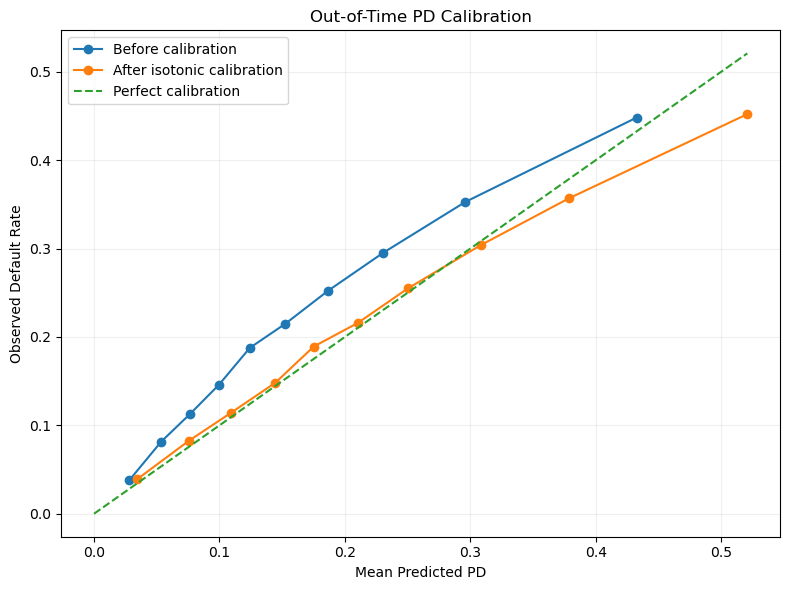

In [24]:
prob_true_before, prob_pred_before = calibration_curve(
    y_test,
    p_test_lgbm,
    n_bins=10,
    strategy="quantile"
)

prob_true_after, prob_pred_after = calibration_curve(
    y_test,
    p_test_cal,
    n_bins=10,
    strategy="quantile"
)

plt.figure(figsize=(8, 6))

plt.plot(
    prob_pred_before,
    prob_true_before,
    marker="o",
    label="Before calibration"
)

plt.plot(
    prob_pred_after,
    prob_true_after,
    marker="o",
    label="After isotonic calibration"
)

upper = max(
    prob_pred_before.max(),
    prob_pred_after.max(),
    prob_true_before.max(),
    prob_true_after.max()
)

plt.plot([0, upper], [0, upper], "--", label="Perfect calibration")

plt.xlabel("Mean Predicted PD")
plt.ylabel("Observed Default Rate")
plt.title("Out-of-Time PD Calibration")
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()


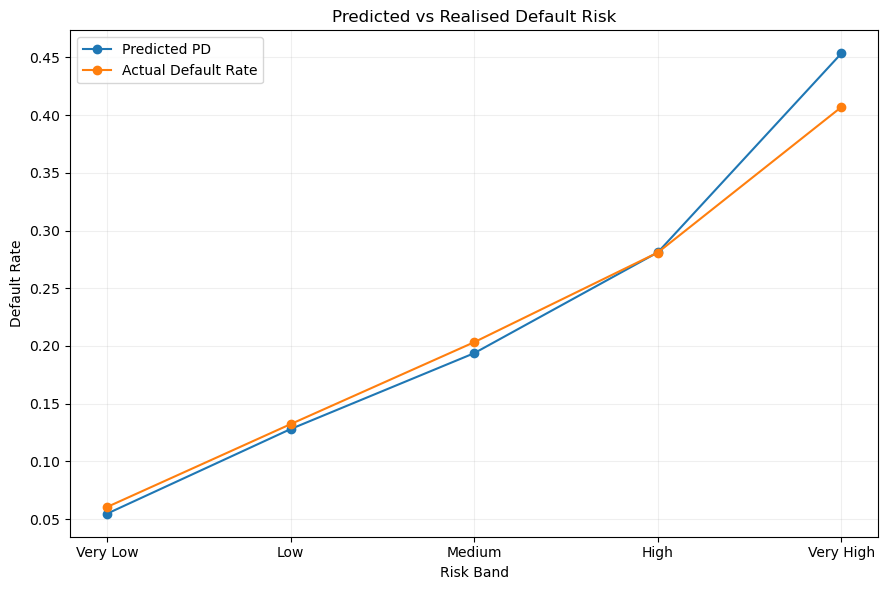

In [25]:
risk_plot = risk_summary.reset_index()

x = range(len(risk_plot))

plt.figure(figsize=(9, 6))

plt.plot(
    x,
    risk_plot["avg_pd"],
    marker="o",
    label="Predicted PD"
)

plt.plot(
    x,
    risk_plot["actual_default_rate"],
    marker="o",
    label="Actual Default Rate"
)

plt.xticks(x, risk_plot["risk_band"])
plt.ylabel("Default Rate")
plt.xlabel("Risk Band")
plt.title("Predicted vs Realised Default Risk")
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()


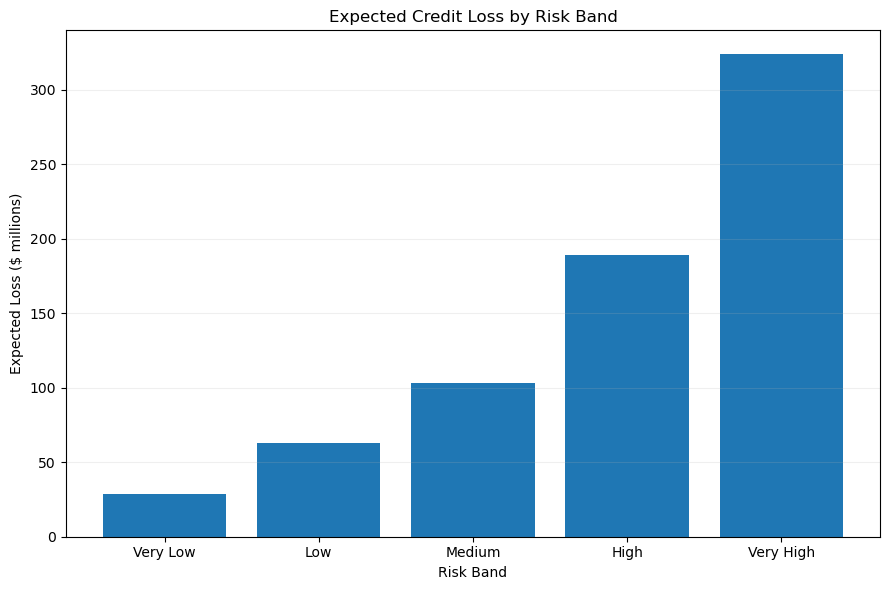

In [26]:
plt.figure(figsize=(9, 6))

plt.bar(
    risk_plot["risk_band"],
    risk_plot["expected_loss"] / 1e6
)

plt.xlabel("Risk Band")
plt.ylabel("Expected Loss ($ millions)")
plt.title("Expected Credit Loss by Risk Band")
plt.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.show()


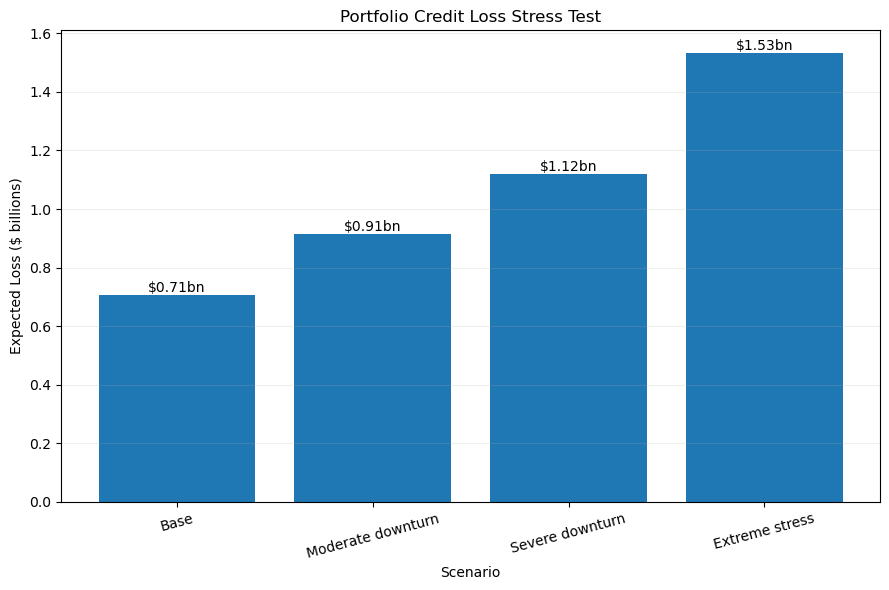

In [27]:
stress_plot = stress_table.copy()

plt.figure(figsize=(9, 6))

bars = plt.bar(
    stress_plot["scenario"],
    stress_plot["expected_loss"] / 1e9
)

plt.ylabel("Expected Loss ($ billions)")
plt.xlabel("Scenario")
plt.title("Portfolio Credit Loss Stress Test")
plt.xticks(rotation=15)

for bar, value in zip(
    bars,
    stress_plot["expected_loss"] / 1e9
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"${value:.2f}bn",
        ha="center",
        va="bottom"
    )

plt.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.show()


## 12. Conclusions and Limitations

The project demonstrates an end-to-end credit-risk framework that connects borrower-level machine-learning predictions with portfolio expected-loss measurement.

### Key Findings

Key results from the final model are:

- LightGBM improved out-of-time discrimination relative to Logistic Regression.
- Out-of-time LightGBM ROC-AUC was approximately **0.7071** and KS was **0.3000**.
- Isotonic calibration improved absolute PD estimation, producing a mean test PD of approximately **21.74%** versus a realised default rate of **21.29%**.
- Mature historical LGD was approximately **89.62%**.
- Base portfolio expected loss was approximately **$706.9 million**.
- Severe stress increased expected loss to approximately **$1.118 billion**, around **58.16% above base case**.

### Limitations

- The 2017–2018 test sample contains only loans with resolved outcomes and may therefore suffer from maturity-selection bias.
- LGD is reconstructed from Lending Club repayment and recovery fields rather than directly observed bank accounting exposure at default.
- Interest rate partly embeds Lending Club's own underwriting assessment.
- Stress scenarios are illustrative sensitivity tests rather than regulatory macroeconomic scenarios.
- Lending Club represents unsecured consumer credit; results should not be directly generalised to corporate or wholesale credit portfolios.
